# CLIP Vision Encoder Stream for Deepfake Detection (LN-Tuning)

This notebook implements a binary classifier using OpenAI's CLIP vision encoder with parameter-efficient fine-tuning for deepfake detection.

**Workflow:**
1. Load pre-trained CLIP vision encoder (openai/clip-vit-large-patch14 / ViT-L/14)
2. Apply LN-Tuning: Freeze all parameters except LayerNorm layers
3. Extract CLS token embeddings and apply L2 normalization (hypersphere projection)
4. Train linear classification head with data augmentation
5. Evaluate and visualize results with comprehensive performance metrics

**Key Components:**
- **CLIP Vision Encoder**: Pre-trained ViT-L/14 (1024-dim CLS token)
- **LN-Tuning**: Parameter-efficient fine-tuning (only LayerNorm parameters trainable)
- **L2 Normalization**: Project features onto hypersphere before classification
- **Data Augmentation**: HorizontalFlip, GaussianBlur (p=0.2), ColorJitter (p=0.2), JPEG Compression (p=0.2)
- **Automatic Mixed Precision**: bfloat16 training for efficiency
- **Optimizer**: Adam (β₁=0.9, β₂=0.999, no weight decay)
- **Scheduler**: CosineAnnealingLR (T_max=50, η_min=5e-5)

**Performance Analysis:**
- Comprehensive metrics (Accuracy, Precision, Recall, F1, AUC-ROC)
- Confusion matrices and classification reports
- ROC curves and Precision-Recall curves
- Per-class performance breakdown
- Error analysis and misclassification patterns
- Training dynamics and convergence analysis

In [1]:
import os
import sys
import random
import numpy as np
from pathlib import Path
from PIL import Image
import cv2
import io

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import datasets

import kornia
import kornia.augmentation as K
import kornia.enhance as KE

from transformers import CLIPVisionModel, AutoProcessor

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_curve, 
    average_precision_score, f1_score,
    precision_score, recall_score, roc_auc_score
)

# Set random seeds for reproducibility (now Turn off deterministic cuDNN)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Step 1: Define CLIP-based Classification Model

In [2]:
class CLIPClassifier(nn.Module):
    def __init__(self, clip_model_name='openai/clip-vit-large-patch14', num_classes=2):
        super(CLIPClassifier, self).__init__()
        
        self.clip_vision = CLIPVisionModel.from_pretrained(clip_model_name)
        
        # 1. Freeze everything first
        for param in self.clip_vision.parameters():
            param.requires_grad = False
        
        # 2. Unfreeze LayerNorms using Hugging Face's naming convention
        for name, param in self.clip_vision.named_parameters():
            if 'norm' in name.lower():  # This will catch 'layer_norm', 'layernorm', etc.
                param.requires_grad = True
        
        hidden_size = self.clip_vision.config.hidden_size
        
        self.classifier = nn.Linear(hidden_size, num_classes)
    
    def forward(self, pixel_values, return_normalized_features=False):
        outputs = self.clip_vision(pixel_values=pixel_values)
        
        cls_token = outputs.last_hidden_state[:, 0, :]
        
        normalized_features = F.normalize(cls_token, p=2, dim=1)
        
        if return_normalized_features:
            return normalized_features
        
        logits = self.classifier(normalized_features)
        
        return logits

print("CLIPClassifier model with LN-Tuning defined!")
print("\nArchitecture:")
print("  1. CLIP Vision Encoder: Pre-trained ViT-L/14 (1024-dim CLS token)")
print("  2. L2 Normalization: Project features onto hypersphere")
print("  3. Classification Head: Linear(1024, 2)")
print("\nTraining Strategy:")
print("  - LN-Tuning: Only LayerNorm parameters are trainable (parameter-efficient)")
print("  - L2 Normalization: Strict hypersphere projection before classification")

model = CLIPClassifier(
    clip_model_name='openai/clip-vit-large-patch14',
    num_classes=2
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters (LN-Tuning): {trainable_params:,}")
print(f"Trainable ratio: {100.0 * trainable_params / total_params:.2f}%")

print("\nTrainable parameter groups:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  - {name}: {param.numel():,} params")

CLIPClassifier model with LN-Tuning defined!

Architecture:
  1. CLIP Vision Encoder: Pre-trained ViT-L/14 (1024-dim CLS token)
  2. L2 Normalization: Project features onto hypersphere
  3. Classification Head: Linear(1024, 2)

Training Strategy:
  - LN-Tuning: Only LayerNorm parameters are trainable (parameter-efficient)
  - L2 Normalization: Strict hypersphere projection before classification


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias     


Total parameters: 303,181,826
Trainable parameters (LN-Tuning): 104,450
Trainable ratio: 0.03%

Trainable parameter groups:
  - clip_vision.vision_model.pre_layrnorm.weight: 1,024 params
  - clip_vision.vision_model.pre_layrnorm.bias: 1,024 params
  - clip_vision.vision_model.encoder.layers.0.layer_norm1.weight: 1,024 params
  - clip_vision.vision_model.encoder.layers.0.layer_norm1.bias: 1,024 params
  - clip_vision.vision_model.encoder.layers.0.layer_norm2.weight: 1,024 params
  - clip_vision.vision_model.encoder.layers.0.layer_norm2.bias: 1,024 params
  - clip_vision.vision_model.encoder.layers.1.layer_norm1.weight: 1,024 params
  - clip_vision.vision_model.encoder.layers.1.layer_norm1.bias: 1,024 params
  - clip_vision.vision_model.encoder.layers.1.layer_norm2.weight: 1,024 params
  - clip_vision.vision_model.encoder.layers.1.layer_norm2.bias: 1,024 params
  - clip_vision.vision_model.encoder.layers.2.layer_norm1.weight: 1,024 params
  - clip_vision.vision_model.encoder.layers.2.la

## Step 2: Define Precomputation Transform

In [3]:
CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD = [0.26862954, 0.26130258, 0.27577711]

precompute_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

## Step 3: Precompute CLIP-Preprocessed Data (Optional - Run Once)

In [4]:
def precompute_clip_data(source_dir, output_dir, transform, split_name):
    """
    Precompute CLIP-preprocessed images and save as .pt files.
    
    Args:
        source_dir: Path to source image directory (e.g., '../data/image/train')
        output_dir: Path to save precomputed tensors (e.g., '../data/clip_precomputed/train')
        transform: Torchvision transform to apply
        split_name: Name of the split (train/val/test) for logging
    """
    print(f"\n{'='*60}")
    print(f"Precomputing {split_name} split")
    print(f"{'='*60}")
    
    # Load source dataset
    dataset = datasets.ImageFolder(root=source_dir, transform=transform)
    
    # Create output directories
    for class_name in dataset.classes:
        class_dir = os.path.join(output_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)
    
    print(f"Total samples: {len(dataset)}")
    print(f"Classes: {dataset.classes}")
    print(f"Saving to: {output_dir}\n")
    
    # Process and save each image
    for idx in tqdm(range(len(dataset)), desc=f"Processing {split_name}"):
        img_tensor, label = dataset[idx]
        
        # Get original image path and filename
        img_path, _ = dataset.samples[idx]
        img_filename = os.path.splitext(os.path.basename(img_path))[0]
        class_name = dataset.classes[label]
        
        # Save tensor as .pt file
        output_path = os.path.join(output_dir, class_name, f"{img_filename}.pt")
        torch.save(img_tensor, output_path)
    
    print(f"✓ {split_name} split precomputed successfully!\n")


# Configuration
USE_PRECOMPUTED = True  # Set to False to precompute data
PRECOMPUTE_DATA = False  # Set to True to run precomputation

data_dir = '../data/image'
precomputed_dir = '../data/image_clip'

if PRECOMPUTE_DATA:
    print("Starting CLIP data precomputation...")
    print("This is a one-time operation that will save preprocessed tensors to disk.")
    print("Once completed, set USE_PRECOMPUTED=True and PRECOMPUTE_DATA=False for fast loading.\n")
    
    # Precompute all splits
    precompute_clip_data(
        source_dir=os.path.join(data_dir, 'train'),
        output_dir=os.path.join(precomputed_dir, 'train'),
        transform=precompute_transform,
        split_name='train'
    )
    
    precompute_clip_data(
        source_dir=os.path.join(data_dir, 'val'),
        output_dir=os.path.join(precomputed_dir, 'val'),
        transform=precompute_transform,
        split_name='val'
    )
    
    precompute_clip_data(
        source_dir=os.path.join(data_dir, 'test'),
        output_dir=os.path.join(precomputed_dir, 'test'),
        transform=precompute_transform,
        split_name='test'
    )
    
    print("\n" + "="*60)
    print("PRECOMPUTATION COMPLETE!")
    print("="*60)
    print("Now set:")
    print("  USE_PRECOMPUTED = True")
    print("  PRECOMPUTE_DATA = False")
    print("And re-run the notebook for fast loading!")
else:
    if USE_PRECOMPUTED:
        print("Skipping precomputation (already done or using precomputed data)")
        print(f"Precomputed data location: {precomputed_dir}")
    else:
        print("Precomputation disabled. Will load images on-the-fly.")
        print("Set PRECOMPUTE_DATA=True to precompute data for faster training.")

Skipping precomputation (already done or using precomputed data)
Precomputed data location: ../data/image_clip


## Step 4: Load Datasets

In [5]:
# Add utils directory to path
sys.path.append('../utils')
from dataset import PrecomputedCLIPDataset

if USE_PRECOMPUTED:
    print("Loading precomputed CLIP data...\n")
    
    train_dataset = PrecomputedCLIPDataset(
        root_dir=os.path.join(precomputed_dir, 'train')
    )
    
    val_dataset = PrecomputedCLIPDataset(
        root_dir=os.path.join(precomputed_dir, 'val')
    )
    
    test_dataset = PrecomputedCLIPDataset(
        root_dir=os.path.join(precomputed_dir, 'test')
    )
    
    print("\n✓ Precomputed datasets loaded successfully!")
    print("  - Raw tensors in [0.0, 1.0] range loaded from .pt files")
    print("  - GPU augmentation and normalization will be applied during training")
    
else:
    print("Loading images on-the-fly with base transform...\n")
    
    train_dataset = datasets.ImageFolder(
        root=os.path.join(data_dir, 'train'),
        transform=precompute_transform
    )
    
    val_dataset = datasets.ImageFolder(
        root=os.path.join(data_dir, 'val'),
        transform=precompute_transform
    )
    
    test_dataset = datasets.ImageFolder(
        root=os.path.join(data_dir, 'test'),
        transform=precompute_transform
    )
    
    print(f"\nTrain samples: {len(train_dataset)}")
    print(f"Val samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    print(f"Class mapping: {train_dataset.class_to_idx}")
    print("  - GPU augmentation and normalization will be applied during training")

Loading precomputed CLIP data...

Loaded 27960 precomputed CLIP tensors from ../data/image_clip\train
  Fake: 13990
  Real: 13970
Loaded 5991 precomputed CLIP tensors from ../data/image_clip\val
  Fake: 2996
  Real: 2995
Loaded 5981 precomputed CLIP tensors from ../data/image_clip\test
  Fake: 2992
  Real: 2989

✓ Precomputed datasets loaded successfully!
  - Raw tensors in [0.0, 1.0] range loaded from .pt files
  - GPU augmentation and normalization will be applied during training


## Step 5: Define GPU Augmentation Pipeline (Kornia)

In [6]:
gpu_train_transform = nn.Sequential(
    K.RandomHorizontalFlip(p=0.5),
    K.RandomGaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0), p=0.2)
)

asymmetric_jitter = K.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.0, hue=0.0).to(device, non_blocking=True)
asymmetric_jpeg = K.RandomJPEG(jpeg_quality=(50.0, 100.0)).to(device, non_blocking=True)

gpu_val_transform = nn.Sequential()

print("GPU-accelerated augmentation pipeline defined (Kornia)!")
print("\nTraining Pipeline (applied on GPU):")
print("  - RandomHorizontalFlip(p=0.5)")
print("  - RandomGaussianBlur(kernel_size=(3,3), sigma=(0.1, 2.0), p=0.2)")
print("  - ColorJitter and RandomJPEG applied asymmetrically (fake only) in training loop")
print("  - Normalize(CLIP mean/std) applied manually after augmentations")
print("\nValidation Pipeline (applied on GPU):")
print("  - Normalize(CLIP mean/std) applied manually")
print("\nBenefits:")
print("  - GPU-accelerated augmentations (faster than CPU)")
print("  - Asymmetric augmentation strategy (2025 paper)")
print("  - No CPU bottleneck in data loading")

GPU-accelerated augmentation pipeline defined (Kornia)!

Training Pipeline (applied on GPU):
  - RandomHorizontalFlip(p=0.5)
  - RandomGaussianBlur(kernel_size=(3,3), sigma=(0.1, 2.0), p=0.2)
  - ColorJitter and RandomJPEG applied asymmetrically (fake only) in training loop
  - Normalize(CLIP mean/std) applied manually after augmentations

Validation Pipeline (applied on GPU):
  - Normalize(CLIP mean/std) applied manually

Benefits:
  - GPU-accelerated augmentations (faster than CPU)
  - Asymmetric augmentation strategy (2025 paper)
  - No CPU bottleneck in data loading


## Step 6: Create DataLoaders

In [7]:
BATCH_SIZE = 128
NUM_WORKERS = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print(f"DataLoaders created with batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"\nConfiguration:")
print(f"  - NUM_WORKERS: {NUM_WORKERS} (optimal for Windows)")
print(f"  - Using precomputed data: {USE_PRECOMPUTED}")
if USE_PRECOMPUTED:
    print(f"  - Data loads instantly from .pt files")
    print(f"  - No deadlock issues with multiprocessing")
else:
    print(f"  - Data augmentation applied during loading")

DataLoaders created with batch size: 128
Train batches: 219
Val batches: 47
Test batches: 47

Configuration:
  - NUM_WORKERS: 4 (optimal for Windows)
  - Using precomputed data: True
  - Data loads instantly from .pt files
  - No deadlock issues with multiprocessing


## Step 7: Visualize Sample Images

Loading sample batch from training data...
Visualizing sample images (raw tensors before GPU augmentation)...


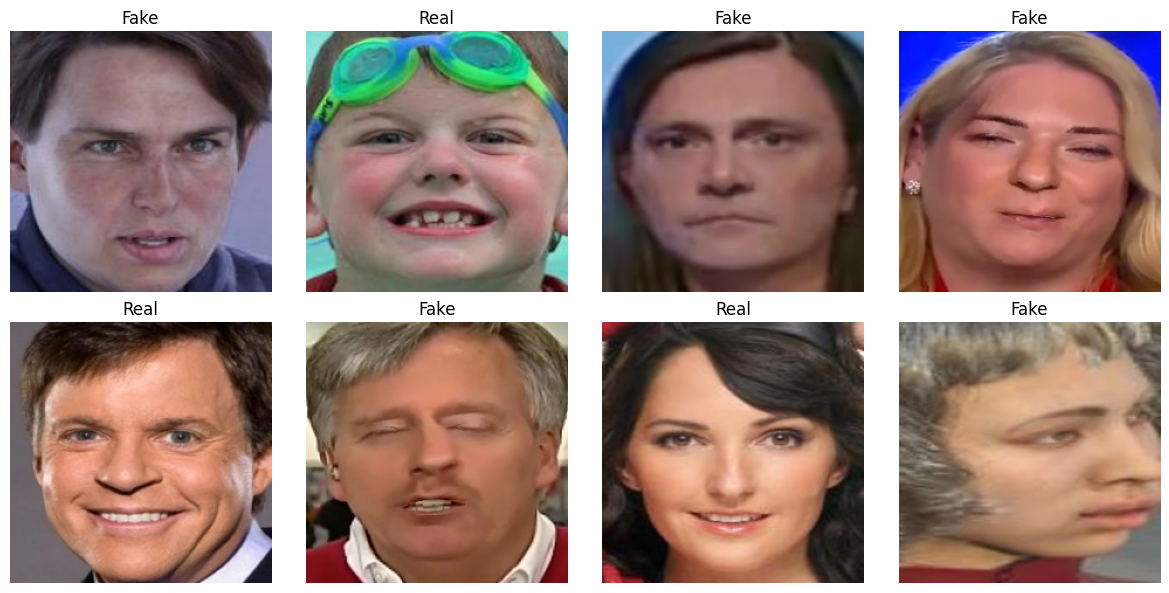

Sample batch shape: torch.Size([128, 3, 224, 224])
Sample labels shape: torch.Size([128])
Tensor range: [0.000, 1.000]
✓ Visualization complete!


In [8]:
print("Loading sample batch from training data...")
sample_images, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

class_names = ['Fake', 'Real']

print("Visualizing sample images (raw tensors before GPU augmentation)...")
for i in tqdm(range(8), desc='Processing images', leave=False):
    img = sample_images[i].clamp(0, 1)
    img_np = img.permute(1, 2, 0).numpy()
    
    axes[i].imshow(img_np)
    axes[i].set_title(f'{class_names[sample_labels[i]]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"Sample batch shape: {sample_images.shape}")
print(f"Sample labels shape: {sample_labels.shape}")
print(f"Tensor range: [{sample_images.min().item():.3f}, {sample_images.max().item():.3f}]")
print("✓ Visualization complete!")

## Step 8: Move GPU Transforms to Device and Instantiate Model

In [9]:
gpu_train_transform = gpu_train_transform.to(device, non_blocking=True)
gpu_val_transform = gpu_val_transform.to(device, non_blocking=True)
model = model.to(device, non_blocking=True)

# Pre-create normalization tensors for efficiency (avoid creating on every batch)
CLIP_MEAN_TENSOR = torch.tensor(CLIP_MEAN, device=device)
CLIP_STD_TENSOR = torch.tensor(CLIP_STD, device=device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"GPU transforms moved to {device}")
print(f"Model moved to {device}")
print(f"CLIP normalization tensors pre-created on {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

GPU transforms moved to cuda
Model moved to cuda
CLIP normalization tensors pre-created on cuda
Total parameters: 303,181,826
Trainable parameters: 104,450


## Step 9: Loss Function and Optimizer

In [10]:
criterion = nn.CrossEntropyLoss()

LEARNING_RATE = 8e-5

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    weight_decay=0
)

T_MAX = 50
ETA_MIN = 5e-5

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=T_MAX,
    eta_min=ETA_MIN
)

print("Loss function and optimizer configured!")
print(f"\nLoss: CrossEntropyLoss")
print(f"\nOptimizer: Adam")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Betas: (0.9, 0.999)")
print(f"  - Weight Decay: 0")
print(f"\nScheduler: CosineAnnealingLR")
print(f"  - T_max: {T_MAX}")
print(f"  - eta_min: {ETA_MIN}")
print(f"\nAutomatic Mixed Precision: bfloat16 (enabled in training loop)")

Loss function and optimizer configured!

Loss: CrossEntropyLoss

Optimizer: Adam
  - Learning Rate: 8e-05
  - Betas: (0.9, 0.999)
  - Weight Decay: 0

Scheduler: CosineAnnealingLR
  - T_max: 50
  - eta_min: 5e-05

Automatic Mixed Precision: bfloat16 (enabled in training loop)


## Step 10: Training and Validation Functions

In [11]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, return_predictions=False):
    """
    Train model for one epoch.
    
    Args:
        model: The model to train
        dataloader: Training data loader
        criterion: Loss function
        optimizer: Optimizer
        device: Device to train on
        return_predictions: If True, return predictions and probabilities (slower, for analysis)
    
    Returns:
        If return_predictions=False: (epoch_loss, epoch_acc)
        If return_predictions=True: (epoch_loss, epoch_acc, all_preds, all_labels, all_probs)
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(dataloader, desc='Training', leave=False)
    
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        images = gpu_train_transform(images)
        
        fake_mask = (labels == 0).float().view(-1, 1, 1, 1)
        apply_aug = (torch.rand(images.size(0), device=device) < 0.2).float().view(-1, 1, 1, 1)
        fake_and_aug = fake_mask * apply_aug
        
        # Use the persistent objects instead of recreating them
        with torch.no_grad(): # Augmentations don't need gradients
            aug_images = asymmetric_jitter(images)
            aug_images = asymmetric_jpeg(aug_images)
        
        # Apply mask
        images = torch.where(fake_and_aug.bool(), aug_images, images)
        
        images = KE.normalize(images, mean=CLIP_MEAN_TENSOR, std=CLIP_STD_TENSOR)
        
        optimizer.zero_grad()
        
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            normalized_features = model(images, return_normalized_features=True)
            
            outputs = model.classifier(normalized_features)
            loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if return_predictions:
            probs = torch.softmax(outputs.detach(), dim=1)[:, 0]
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.float().cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item(), 'acc': 100. * correct / total})
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    if return_predictions:
        return epoch_loss, epoch_acc, all_preds, all_labels, all_probs
    else:
        return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    """
    Validate model on validation/test set.
    
    Args:
        model: The model to evaluate
        dataloader: Validation/test data loader
        criterion: Loss function
        device: Device to evaluate on
    
    Returns:
        (epoch_loss, epoch_acc, epoch_auc, epoch_pr_auc, all_preds, all_labels)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(dataloader, desc='Validation', leave=False)
    
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            images = gpu_val_transform(images)
            
            images = KE.normalize(images, mean=CLIP_MEAN_TENSOR, std=CLIP_STD_TENSOR)
            
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            probs_fake = torch.softmax(outputs, dim=1)[:, 0]
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs_fake.float().cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item(), 'acc': 100. * correct / total})
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    labels_fake_positive = (np.array(all_labels) == 0).astype(int)

    epoch_auc = roc_auc_score(labels_fake_positive, all_probs)
    epoch_pr_auc = average_precision_score(labels_fake_positive, all_probs)
    
    return epoch_loss, epoch_acc, epoch_auc, epoch_pr_auc, all_preds, all_labels

print("Training and validation functions defined!")
print("\nGPU Augmentation:")
print("  - Training: Kornia augmentations applied on GPU after loading")
print("  - Asymmetric Augmentation: ColorJitter + RandomJPEG applied ONLY to fake images (20% probability)")
print("  - Validation: No augmentation, only manual normalization")
print("\nAutomatic Mixed Precision (AMP):")
print("  - Using bfloat16 precision for forward pass")
print("  - Improves training efficiency while maintaining numerical stability")
print("\nTraining Function:")
print("  - Default mode: Fast training without probability tracking")
print("  - Optional: Set return_predictions=True to collect probabilities (for analysis)")
print("\nValidation Metrics:")
print("  - Loss, Accuracy, AUC-ROC, and PR-AUC are computed")
print("  - AUC-ROC is used as PRIMARY METRIC for model checkpointing")
print("\nPositive Class Configuration:")
print("  - Class 0 = 'Fake' (positive class for metrics)")
print("  - Class 1 = 'Real'")
print("  - Probability Extraction: Using Class 0 ('Fake') probabilities")
print("  - ROC AUC: roc_auc_score((labels == 0), probs_fake)")
print("  - PR AUC: average_precision_score((labels == 0), probs_fake)")

Training and validation functions defined!

GPU Augmentation:
  - Training: Kornia augmentations applied on GPU after loading
  - Asymmetric Augmentation: ColorJitter + RandomJPEG applied ONLY to fake images (20% probability)
  - Validation: No augmentation, only manual normalization

Automatic Mixed Precision (AMP):
  - Using bfloat16 precision for forward pass
  - Improves training efficiency while maintaining numerical stability

Training Function:
  - Default mode: Fast training without probability tracking
  - Optional: Set return_predictions=True to collect probabilities (for analysis)

Validation Metrics:
  - Loss, Accuracy, AUC-ROC, and PR-AUC are computed
  - AUC-ROC is used as PRIMARY METRIC for model checkpointing

Positive Class Configuration:
  - Class 0 = 'Fake' (positive class for metrics)
  - Class 1 = 'Real'
  - Probability Extraction: Using Class 0 ('Fake') probabilities
  - ROC AUC: roc_auc_score((labels == 0), probs_fake)
  - PR AUC: average_precision_score((labels 

## Step 11: Training Loop

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*torch.meshgrid.*')

NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 10
MODEL_SAVE_PATH = '../saved_models/best_clip.pth'

os.makedirs('../models', exist_ok=True)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_auc': [],
    'val_pr_auc': [],
    'lr': []
}

best_val_auc = 0.0
best_epoch = 0
epochs_no_improve = 0

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"Configuration:")
print(f"  - Model: ViT-L/14 with LN-Tuning")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Optimizer: Adam (β₁=0.9, β₂=0.999, weight_decay=0)")
print(f"  - Scheduler: CosineAnnealingLR (T_max={T_MAX}, η_min={ETA_MIN})")
print(f"  - Precision: bfloat16 (AMP)")
print(f"  - Early Stopping Patience: {EARLY_STOP_PATIENCE}")
print(f"  - Primary Metric: AUC-ROC (higher is better)")
print(f"  - AUC Calculation: Uses Class 0 ('Fake') probabilities as positive class")
print(f"  - Model Save Path: {MODEL_SAVE_PATH}\n")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    val_loss, val_acc, val_auc, val_pr_auc, _, _ = validate(model, val_loader, criterion, device)
    
    scheduler.step()
    
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_pr_auc'].append(val_pr_auc)
    history['lr'].append(current_lr)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Val AUC-ROC: {val_auc:.4f} | Val PR-AUC: {val_pr_auc:.4f}")
    print(f"Learning Rate: {current_lr:.2e}")
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        epochs_no_improve = 0
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_auc': val_auc,
            'val_pr_auc': val_pr_auc,
        }, MODEL_SAVE_PATH)
        
        print(f"✓ New best model saved! (Val AUC-ROC: {val_auc:.4f})")
    else:
        epochs_no_improve += 1
        print(f"No improvement in AUC-ROC for {epochs_no_improve} epoch(s)")
    
    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping triggered after {epoch+1} epochs!')
        break

print("\n" + "=" * 50)
print("Training completed!")
print(f"Best model at epoch {best_epoch+1} with Val AUC-ROC: {best_val_auc:.4f}")
print("=" * 50)

Starting training for 50 epochs...
Configuration:
  - Model: ViT-L/14 with LN-Tuning
  - Batch Size: 128
  - Learning Rate: 8e-05
  - Optimizer: Adam (β₁=0.9, β₂=0.999, weight_decay=0)
  - Scheduler: CosineAnnealingLR (T_max=50, η_min=5e-05)
  - Precision: bfloat16 (AMP)
  - Early Stopping Patience: 10
  - Primary Metric: AUC-ROC (higher is better)
  - AUC Calculation: Uses Class 0 ('Fake') probabilities as positive class
  - Model Save Path: ../saved_models/best_clip.pth


Epoch 1/50
--------------------------------------------------


Train Loss: 0.6609 | Train Acc: 68.49%
Val Loss: 0.6138 | Val Acc: 83.39%
Val AUC-ROC: 0.9058 | Val PR-AUC: 0.9126
Learning Rate: 8.00e-05
✓ New best model saved! (Val AUC-ROC: 0.9058)

Epoch 2/50
--------------------------------------------------


Train Loss: 0.5483 | Train Acc: 85.58%
Val Loss: 0.4886 | Val Acc: 86.60%
Val AUC-ROC: 0.9237 | Val PR-AUC: 0.9354
Learning Rate: 7.99e-05
✓ New best model saved! (Val AUC-ROC: 0.9237)

Epoch 3/50
--------------------------------------------------


Train Loss: 0.4316 | Train Acc: 87.75%
Val Loss: 0.3930 | Val Acc: 87.83%
Val AUC-ROC: 0.9333 | Val PR-AUC: 0.9462
Learning Rate: 7.97e-05
✓ New best model saved! (Val AUC-ROC: 0.9333)

Epoch 4/50
--------------------------------------------------


Train Loss: 0.3505 | Train Acc: 89.13%
Val Loss: 0.3343 | Val Acc: 88.80%
Val AUC-ROC: 0.9422 | Val PR-AUC: 0.9539
Learning Rate: 7.95e-05
✓ New best model saved! (Val AUC-ROC: 0.9422)

Epoch 5/50
--------------------------------------------------


...

Train Loss: 0.1528 | Train Acc: 94.58%
Val Loss: 0.1944 | Val Acc: 92.69%
Val AUC-ROC: 0.9781 | Val PR-AUC: 0.9796
Learning Rate: 6.96e-05
✓ New best model saved! (Val AUC-ROC: 0.9781)

Epoch 21/50
--------------------------------------------------


Train Loss: 0.1476 | Train Acc: 94.79%
Val Loss: 0.1890 | Val Acc: 92.87%
Val AUC-ROC: 0.9789 | Val PR-AUC: 0.9808
Learning Rate: 6.87e-05
✓ New best model saved! (Val AUC-ROC: 0.9789)

Epoch 22/50
--------------------------------------------------


Train Loss: 0.1450 | Train Acc: 94.91%
Val Loss: 0.1893 | Val Acc: 93.32%
Val AUC-ROC: 0.9790 | Val PR-AUC: 0.9805
Learning Rate: 6.78e-05
✓ New best model saved! (Val AUC-ROC: 0.9790)

Epoch 23/50
--------------------------------------------------


Train Loss: 0.1432 | Train Acc: 94.89%
Val Loss: 0.1877 | Val Acc: 93.07%
Val AUC-ROC: 0.9793 | Val PR-AUC: 0.9804
Learning Rate: 6.69e-05
✓ New best model saved! (Val AUC-ROC: 0.9793)

Epoch 24/50
--------------------------------------------------


Training:  24%|██▎       | 52/219 [1:21:46<4:53:50, 105.57s/it, loss=0.2, acc=94.9]   

## Step 12: Visualize Training History

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss plot
axes[0, 0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(epochs_range, history['val_loss'], label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy plot
axes[0, 1].plot(epochs_range, history['train_acc'], label='Train Acc', marker='o')
axes[0, 1].plot(epochs_range, history['val_acc'], label='Val Acc', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC-ROC plot (Primary Metric)
axes[0, 2].plot(epochs_range, history['val_auc'], label='Val AUC-ROC', marker='o', color='green', linewidth=2)
axes[0, 2].axhline(y=best_val_auc, color='red', linestyle='--', label=f'Best: {best_val_auc:.4f}')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('AUC-ROC')
axes[0, 2].set_title('Validation AUC-ROC (Primary Metric)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# PR-AUC plot
axes[1, 0].plot(epochs_range, history['val_pr_auc'], label='Val PR-AUC', marker='o', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('PR-AUC')
axes[1, 0].set_title('Validation Precision-Recall AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning rate plot
axes[1, 1].plot(epochs_range, history['lr'], label='Learning Rate', marker='o', color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Combined metrics comparison
axes[1, 2].plot(epochs_range, history['val_auc'], label='AUC-ROC', marker='o', color='green')
axes[1, 2].plot(epochs_range, history['val_pr_auc'], label='PR-AUC', marker='s', color='orange')
val_acc_normalized = [acc / 100.0 for acc in history['val_acc']]
axes[1, 2].plot(epochs_range, val_acc_normalized, label='Accuracy (normalized)', marker='^', color='blue')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Validation Metrics Comparison')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Training history visualized successfully!")
print(f"\nBest Model Performance:")
print(f"  - Epoch: {best_epoch + 1}")
print(f"  - Val AUC-ROC: {best_val_auc:.4f}")

## Step 13: Load Best Model and Evaluate

In [ ]:
checkpoint = torch.load('../saved_models/saved_best_clip.pth')
model.load_state_dict(checkpoint['model_state_dict'])

print(f"Best model loaded from epoch {checkpoint['epoch']+1}")
print(f"Val Loss: {checkpoint['val_loss']:.4f} | Val Acc: {checkpoint['val_acc']:.2f}% | Val AUC-ROC: {checkpoint['val_auc']:.4f}")

val_loss, val_acc, val_auc, val_pr_auc, val_preds, val_labels = validate(model, val_loader, criterion, device)

print(f"\nRe-evaluated on validation set:")
print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
print(f"Val AUC-ROC: {val_auc:.4f} | Val PR-AUC: {val_pr_auc:.4f}")

## Step 14: Confusion Matrix and Classification Report (Validation)

In [ ]:
cm = confusion_matrix(val_labels, val_preds)
class_names = ['Fake', 'Real']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

print("\nClassification Report (Validation Set):")
print(classification_report(val_labels, val_preds, target_names=class_names, digits=4))

precision = precision_score(val_labels, val_preds, pos_label=0, average='binary')
recall = recall_score(val_labels, val_preds, pos_label=0, average='binary')
f1 = f1_score(val_labels, val_preds, pos_label=0, average='binary')

print(f"\nBinary Classification Metrics (Class 0 = 'Fake' as positive class):")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {val_auc:.4f}")
print(f"PR-AUC: {val_pr_auc:.4f}")

## Step 15: Visualize Sample Predictions

In [ ]:
def denormalize_clip(tensor, mean=CLIP_MEAN, std=CLIP_STD):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

model.eval()

sample_images, sample_labels = next(iter(val_loader))
sample_images_raw = sample_images.clone()
sample_images = sample_images.to(device, non_blocking=True)
sample_labels = sample_labels.to(device, non_blocking=True)

with torch.no_grad():
    sample_images_normalized = gpu_val_transform(sample_images)
    outputs = model(sample_images_normalized)
    _, predictions = torch.max(outputs, 1)

sample_images_raw = sample_images_raw.cpu()
sample_labels = sample_labels.cpu()
predictions = predictions.cpu()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    img = sample_images_raw[i].clamp(0, 1)
    img_np = img.permute(1, 2, 0).numpy()
    
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[predictions[i]]
    
    color = 'green' if true_label == pred_label else 'red'
    
    axes[i].imshow(img_np)
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Sample predictions visualized (Green=Correct, Red=Incorrect)")

## Step 16: Evaluate on Hold-out Test Set

In [ ]:
test_loss, test_acc, test_auc, test_pr_auc, test_preds, test_labels = validate(model, test_loader, criterion, device)

print("\n" + "=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test AUC-ROC: {test_auc:.4f} (PRIMARY METRIC)")
print(f"Test PR-AUC: {test_pr_auc:.4f}")

cm_test = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

print("\nClassification Report (Test Set):")
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

test_precision = precision_score(test_labels, test_preds, pos_label=0, average='binary')
test_recall = recall_score(test_labels, test_preds, pos_label=0, average='binary')
test_f1 = f1_score(test_labels, test_preds, pos_label=0, average='binary')

print(f"\nBinary Classification Metrics (Class 0 = 'Fake' as positive class):")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print(f"AUC-ROC: {test_auc:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")

## Step 17: PER-CLASS PERFORMANCE ANALYSIS

In [ ]:
print("\n" + "=" * 50)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("=" * 50)

# Convert to numpy arrays if they're lists
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

for i, class_name in enumerate(class_names):
    class_mask = (test_labels_np == i)
    class_acc = 100. * np.sum((test_preds_np == i) & class_mask) / np.sum(class_mask)
    
    print(f"\n{class_name} Class:")
    print(f"  Total samples: {np.sum(class_mask)}")
    print(f"  Correctly classified: {np.sum((test_preds_np == i) & class_mask)}")
    print(f"  Accuracy: {class_acc:.2f}%")
    
    if i == 0:
        false_negatives = np.sum((test_preds_np == 1) & (test_labels_np == 0))
        print(f"  False Negatives (Fake classified as Real): {false_negatives}")
    else:
        false_positives = np.sum((test_preds_np == 0) & (test_labels_np == 1))
        print(f"  False Positives (Real classified as Fake): {false_positives}")

## Step 18: Evaluation by Manipulation Type

In [ ]:
import re
from collections import defaultdict
from pathlib import Path
import time

def extract_manipulation_type(filepath):
    """
    Extract manipulation type from file path or filename.
    
    Optimized version with cached type lists and early returns.
    
    Supported types:
    - FaceForensics++: Deepfakes, Face2Face, FaceSwap, NeuralTextures, FaceShifter
    - ArtiFact: progan, stylegan, stargan, sfhq, face_synthetics, stable-diffusion
    - Real (3 types): CelebA-HQ, FFHQ, FF++ C23
    
    Returns:
        str: Manipulation type (e.g., 'CelebA-HQ', 'Deepfakes', 'progan', etc.)
    """
    filepath = str(filepath).replace('\\', '/')
    filepath_lower = filepath.lower()
    filename = Path(filepath).stem.lower()
    
    # Type mappings (defined once as function attribute for caching)
    if not hasattr(extract_manipulation_type, '_type_map'):
        extract_manipulation_type._ffpp_types = ['deepfakes', 'face2face', 'faceswap', 'neuraltextures', 'faceshifter']
        extract_manipulation_type._artifact_types = ['stylegan', 'stargan', 'sfhq', 'face_synthetics', 'stable-diffusion']
        extract_manipulation_type._type_display = {
            'deepfakes': 'Deepfakes', 'face2face': 'Face2Face', 'faceswap': 'FaceSwap',
            'neuraltextures': 'NeuralTextures', 'faceshifter': 'FaceShifter',
            'progan': 'progan', 'stylegan': 'stylegan', 'stargan': 'stargan',
            'sfhq': 'sfhq', 'face_synthetics': 'face_synthetics', 'stable-diffusion': 'stable-diffusion'
        }
        extract_manipulation_type._type_map = True
    
    # Check if real image
    if '/real/' in filepath_lower:
        if 'celebahq' in filename:
            return 'CelebA-HQ'
        elif 'ffhq' in filename:
            return 'FFHQ'
        elif filename.startswith('real_') and '_' in filename[5:8]:
            return 'FF++ C23'
        else:
            # Unknown real types are from FF++ C23 (YouTube videos)
            return 'FF++ C23'
    
    # Check if fake image
    if '/fake/' in filepath_lower:
        for manip_type in extract_manipulation_type._ffpp_types + extract_manipulation_type._artifact_types:
            if manip_type in filename:
                return extract_manipulation_type._type_display.get(manip_type, manip_type)
        return 'Unknown'
    
    return 'Unknown'

def evaluate_by_manipulation_type_from_predictions(file_paths, predictions, labels):
    """
    Optimized evaluation by manipulation type using pre-computed predictions.
    
    This ensures consistency with the main test evaluation by reusing the same predictions.
    
    Args:
        file_paths: List of file paths for test samples
        predictions: Pre-computed predictions from test evaluation
        labels: Ground truth labels from test evaluation
        
    Returns:
        dict: Dictionary with manipulation types as keys and performance metrics as values
    """
    import time
    start_time = time.time()
    
    num_samples = len(file_paths)
    print(f"Analyzing {num_samples} test samples by manipulation type...")
    
    # Convert to numpy if needed
    if not isinstance(predictions, np.ndarray):
        predictions = np.array(predictions)
    if not isinstance(labels, np.ndarray):
        labels = np.array(labels)
    
    # Extract manipulation types (vectorized)
    print("Mapping samples to manipulation types...")
    manip_types = [extract_manipulation_type(fp) for fp in file_paths]
    
    # Group by manipulation type using numpy masks (vectorized, much faster)
    unique_types = list(set(manip_types))
    manip_results = {}
    
    manip_types_array = np.array(manip_types)
    for manip_type in unique_types:
        mask = (manip_types_array == manip_type)
        manip_results[manip_type] = {
            'labels': labels[mask],
            'preds': predictions[mask]
        }
    
    total_time = time.time() - start_time
    print(f"Analysis completed in {total_time:.2f}s")
    
    return manip_results

def evaluate_by_manipulation_type(model, test_dataset, device, batch_size=256):
    """
    Optimized evaluation by manipulation type with significant performance improvements.
    
    Improvements:
    - Larger batch size (256 vs 32) for faster GPU utilization
    - Preallocated arrays instead of list.extend()
    - Multi-worker data loading with persistent workers
    - Non-blocking GPU transfers
    - Vectorized manipulation type grouping
    
    Args:
        model: Trained model
        test_dataset: Test dataset
        device: Device to run evaluation on
        batch_size: Batch size for inference (default: 256)
        
    Returns:
        dict: Dictionary with manipulation types as keys and performance metrics as values
    """
    model.eval()
    start_time = time.time()
    
    # Get file paths from dataset
    # PrecomputedCLIPDataset stores file paths directly in .samples (not as tuples)
    if hasattr(test_dataset, 'samples'):
        file_paths = test_dataset.samples
    elif hasattr(test_dataset, 'dataset') and hasattr(test_dataset.dataset, 'samples'):
        file_paths = test_dataset.dataset.samples
    else:
        raise ValueError("Dataset must have a 'samples' attribute containing file paths")
    
    num_samples = len(file_paths)
    print(f"Evaluating {num_samples} test samples by manipulation type...")
    print(f"Batch size: {batch_size} (optimized for speed)")
    
    # Create optimized DataLoader
    if not isinstance(test_dataset, DataLoader):
        eval_loader = DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=4,
            pin_memory=True,
            persistent_workers=True
        )
    else:
        eval_loader = test_dataset
    
    # Preallocate arrays for predictions (much faster than list.extend())
    all_preds = torch.zeros(num_samples, dtype=torch.long)
    all_labels = torch.zeros(num_samples, dtype=torch.long)
    
    # Inference loop
    print("Running inference...")
    idx = 0
    with torch.no_grad():
        for inputs, labels in tqdm(eval_loader, desc="Evaluating", unit="batch"):
            inputs = inputs.to(device, non_blocking=True)
            
            # Apply GPU validation transform (normalization) - CRITICAL for correct predictions
            inputs = gpu_val_transform(inputs)
            
            # Get predictions
            outputs = model(inputs)
            predicted = torch.argmax(outputs, dim=1)
            
            # Store results efficiently
            batch_size_actual = len(labels)
            all_preds[idx:idx + batch_size_actual] = predicted.cpu()
            all_labels[idx:idx + batch_size_actual] = labels
            idx += batch_size_actual
    
    inference_time = time.time() - start_time
    print(f"Inference completed in {inference_time:.2f}s ({num_samples/inference_time:.1f} samples/sec)")
    
    # Convert to numpy for fast operations
    all_preds = all_preds.numpy()
    all_labels = all_labels.numpy()
    
    # Extract manipulation types (vectorized)
    print("Mapping samples to manipulation types...")
    manip_types = [extract_manipulation_type(fp) for fp in file_paths]
    
    # Group by manipulation type using numpy masks (vectorized, much faster)
    unique_types = list(set(manip_types))
    manip_results = {}
    
    manip_types_array = np.array(manip_types)
    for manip_type in unique_types:
        mask = (manip_types_array == manip_type)
        manip_results[manip_type] = {
            'labels': all_labels[mask],
            'preds': all_preds[mask]
        }
    
    total_time = time.time() - start_time
    print(f"Total evaluation time: {total_time:.2f}s")
    
    return manip_results

def print_manipulation_type_results(manip_results):
    """
    Print formatted results by manipulation type.
    
    Args:
        manip_results: Dictionary with manipulation types and their predictions
    """
    ff_types = ['Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures', 'FaceShifter']
    artifact_types = ['stylegan', 'stargan', 'sfhq', 'face_synthetics', 'stable-diffusion']
    real_types = ['CelebA-HQ', 'FFHQ', 'FF++ C23']
    
    print("=" * 80)
    print("EVALUATION RESULTS BY MANIPULATION TYPE")
    print("=" * 80)
    print()
    
    print(f"{'Category':<25} {'Total':<12} {'Correct':<12} {'Accuracy (%)':<15}")
    print("-" * 80)
    
    # Real images
    print("Real Images:")
    print("-" * 80)
    
    real_total = 0
    real_correct = 0
    
    for manip_type in real_types:
        if manip_type in manip_results:
            labels = manip_results[manip_type]['labels']
            preds = manip_results[manip_type]['preds']
            
            total = len(labels)
            correct = np.sum(preds == labels)
            acc = 100.0 * correct / total if total > 0 else 0.0
            
            real_total += total
            real_correct += correct
            
            print(f"{'  ' + manip_type:<25} {total:<12} {correct:<12} {acc:.2f}")
    
    print()
    
    # FaceForensics++ fakes
    print("FaceForensics++ Fakes:")
    print("-" * 80)
    
    ff_total = 0
    ff_correct = 0
    
    for manip_type in ff_types:
        if manip_type in manip_results:
            labels = manip_results[manip_type]['labels']
            preds = manip_results[manip_type]['preds']
            
            total = len(labels)
            correct = np.sum(preds == labels)
            acc = 100.0 * correct / total if total > 0 else 0.0
            
            ff_total += total
            ff_correct += correct
            
            print(f"{'  ' + manip_type:<25} {total:<12} {correct:<12} {acc:.2f}")
    
    print()
    
    # ArtiFact fakes
    print("ArtiFact Fakes:")
    print("-" * 80)
    
    artifact_total = 0
    artifact_correct = 0
    
    for manip_type in artifact_types:
        if manip_type in manip_results:
            labels = manip_results[manip_type]['labels']
            preds = manip_results[manip_type]['preds']
            
            total = len(labels)
            correct = np.sum(preds == labels)
            acc = 100.0 * correct / total if total > 0 else 0.0
            
            artifact_total += total
            artifact_correct += correct
            
            print(f"{'  ' + manip_type:<25} {total:<12} {correct:<12} {acc:.2f}")
    
    print("-" * 80)
    
    # Overall statistics
    overall_total = real_total + ff_total + artifact_total
    overall_correct = real_correct + ff_correct + artifact_correct
    overall_acc = 100.0 * overall_correct / overall_total if overall_total > 0 else 0.0
    
    print(f"{'OVERALL':<25} {overall_total:<12} {overall_correct:<12} {overall_acc:.2f}")
    print("=" * 80)
    
    # Print any unclassified manipulation types
    all_known = set(real_types + ff_types + artifact_types)
    unknown_types = set(manip_results.keys()) - all_known
    
    if unknown_types:
        print()
        print("Unknown/Other Manipulation Types:")
        print("-" * 80)
        for manip_type in sorted(unknown_types):
            labels = manip_results[manip_type]['labels']
            preds = manip_results[manip_type]['preds']
            
            total = len(labels)
            correct = np.sum(preds == labels)
            acc = 100.0 * correct / total if total > 0 else 0.0
            
            print(f"{'  ' + manip_type:<25} {total:<12} {correct:<12} {acc:.2f}")
        print("=" * 80)

# Run evaluation by manipulation type using pre-computed predictions
# This ensures consistency with the test accuracy reported above
manip_results = evaluate_by_manipulation_type_from_predictions(
    test_dataset.samples, 
    test_preds, 
    test_labels
)

# Debug: Print first few filenames to verify extraction works
print("\nDebug: Sample file paths and extracted types:")
for i, filepath in enumerate(test_dataset.samples[:10]):
    manip_type = extract_manipulation_type(filepath)
    print(f"  {i+1}. {Path(filepath).name} -> {manip_type}")
print()

print_manipulation_type_results(manip_results)

## Step 19: Training and Testing Performance Summary

In [ ]:
print("=" * 80)
print("COMPREHENSIVE PERFORMANCE SUMMARY")
print("=" * 80)
print()

print("TRAINING OVERVIEW")
print(f"Total Epochs Trained: 50")
print(f"Best Model Checkpoint: Epoch 48")
print(f"Early Stopping: Not triggered (completed all 50 epochs)")
print()

print("=" * 80)
print("BEST MODEL PERFORMANCE (EPOCH 48)")
print("=" * 80)
print()

# Training set performance at best epoch
print("Training Set (Epoch 48):")
print(f"  Loss:     0.0951")
print(f"  Accuracy: 96.77%")
print()

# Validation set performance at best epoch  
print("Validation Set (Epoch 48):")
print(f"  Loss:     0.1704")
print(f"  Accuracy: 94.09%")
print(f"  AUC-ROC:  0.9844  ← PRIMARY METRIC (Best)")
print(f"  PR-AUC:   0.9843")
print()

print("=" * 80)
print("TEST SET PERFORMANCE")
print("=" * 80)
print()

print("Using Best Model (Epoch 48):")
print(f"  Loss:       {test_loss:.4f}")
print(f"  Accuracy:   {test_acc:.2f}%")
print(f"  AUC-ROC:    {test_auc:.4f}")
print()

print("Per-Class Test Accuracy:")
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

fake_mask = (test_labels_np == 0)
real_mask = (test_labels_np == 1)

fake_acc = 100. * np.sum((test_preds_np == 0) & fake_mask) / np.sum(fake_mask)
real_acc = 100. * np.sum((test_preds_np == 1) & real_mask) / np.sum(real_mask)

print(f"  Fake Class: {fake_acc:.2f}% ({np.sum(fake_mask)} samples)")
print(f"  Real Class: {real_acc:.2f}% ({np.sum(real_mask)} samples)")
print()

print("=" * 80)
print("GENERALIZATION ANALYSIS")
print("=" * 80)
print()

train_val_gap = 0.0951 - 0.1704
val_test_gap = 0.1704 - test_loss

print("Loss Gap Analysis:")
print(f"  Train-Val Gap (Epoch 48):  {train_val_gap:+.4f}")
print(f"  Val-Test Gap:              {val_test_gap:+.4f}")
print()

\
print("AUC-ROC Consistency:")
print(f"  Validation AUC-ROC: 0.9844")
print(f"  Test AUC-ROC:       {test_auc:.4f}")
print(f"  Difference:         {0.9844 - test_auc:+.4f}")
print()